[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 974
[LightGBM] [Info] Number of data points in the train set: 188, number of used features: 17
[LightGBM] [Info] Start training from score 10.927897
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

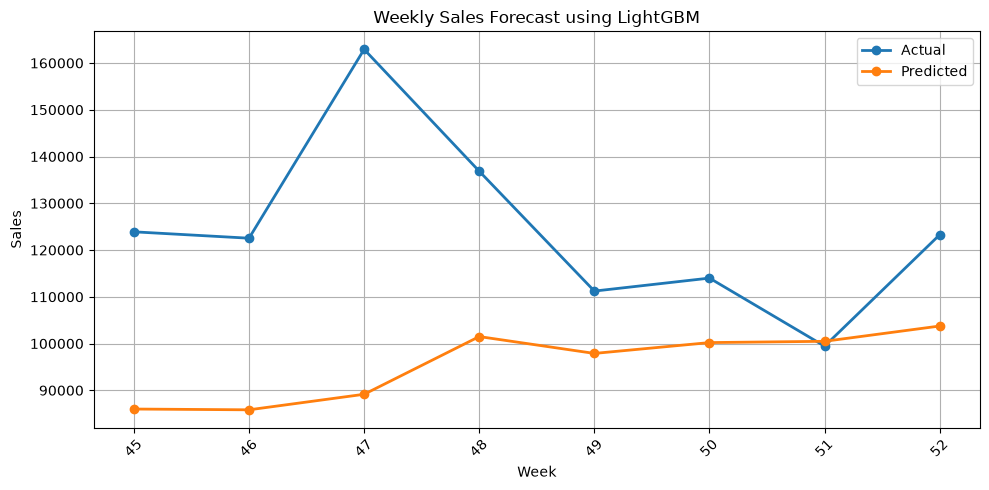


Top Features:
            Feature  Importance
7             lag_4         500
11    rolling_std_4         411
16   expanding_mean         400
9            lag_12         388
1              week         385
4             lag_1         362
8             lag_8         362
2          week_sin         356
10   rolling_mean_4         309
6             lag_3         285
5             lag_2         270
14  rolling_mean_12         234
13    rolling_std_8         216
15   rolling_std_12         198
12   rolling_mean_8         161
3          week_cos         114
0              year          59

Forecast saved as weekly_lightgbm_forecast.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# ===================== LOAD DATA =====================
df = pd.read_csv("../../preprocessing/weekly_sales.csv")
df = df.sort_values(["year", "week"]).reset_index(drop=True)

# ===================== FEATURE ENGINEERING =====================

# Cyclical Week Encoding
df["week_sin"] = np.sin(2 * np.pi * df["week"] / 52)
df["week_cos"] = np.cos(2 * np.pi * df["week"] / 52)

# Lag Features
for lag in [1,2,3,4,8,12]:
    df[f"lag_{lag}"] = df["Total amount"].shift(lag)

# Rolling Statistics
for window in [4,8,12]:
    df[f"rolling_mean_{window}"] = (
        df["Total amount"].shift(1).rolling(window).mean()
    )
    df[f"rolling_std_{window}"] = (
        df["Total amount"].shift(1).rolling(window).std()
    )

# Expanding Mean
df["expanding_mean"] = (
    df["Total amount"]
    .shift(1)
    .expanding()
    .mean()
)

# Remove NA rows
df = df.dropna().reset_index(drop=True)

# ===================== TRAIN TEST SPLIT =====================
train = df.iloc[:-8]
test = df.iloc[-8:]

features = [c for c in df.columns if c != "Total amount"]

X_train = train[features]
X_test = test[features]

y_train = np.log1p(train["Total amount"])
y_test = test["Total amount"]

# ===================== MODEL =====================
model = LGBMRegressor(
    objective="regression",
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

# ===================== PREDICTION =====================
pred = np.expm1(model.predict(X_test)) # type: ignore
pred = np.clip(pred, 0, None)

# ===================== METRICS =====================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = mean_absolute_percentage_error(y_test, pred) * 100

print("=" * 50)
print("LightGBM Weekly Forecast")
print("=" * 50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# ===================== PLOT =====================
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, marker="o", linewidth=2, label="Actual") #type: ignore
plt.plot(range(len(pred)), pred, marker="o", linewidth=2, label="Predicted")
plt.xticks(range(len(y_test)), test["week"].astype(str), rotation=45)  #type: ignore
plt.xlabel("Week")
plt.ylabel("Sales")
plt.title("Weekly Sales Forecast using LightGBM")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===================== FEATURE IMPORTANCE =====================
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Features:")
print(importance)

# ===================== SAVE RESULTS =====================
results = pd.DataFrame({
    "Year": test["year"],
    "Week": test["week"],
    "Actual": y_test.values,
    "Predicted": pred
})

results.to_csv("weekly_lightgbm_forecast.csv", index=False)

print("\nForecast saved as weekly_lightgbm_forecast.csv")